# Accessing OISST data with Icechunk

In [ ]:
import re
from getpass import getpass

import marimo as mo
import icechunk as ic
import numpy as np
import xarray as xr
from pydantic import BaseModel, Field

## S3 credentials

While the daily data is in a regular public bucket (that is paid for through the open data program), the metadata for fast access, and the monthly data are in a requester-pays bucket. NERACOOS pays for the storage costs, but the users pay for the data transfer.

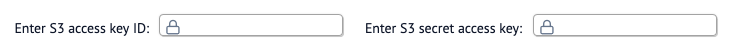

In [ ]:
access_key = mo.ui.text(label="Enter S3 access key ID: ", kind="password")
secret_key = mo.ui.text(label="Enter S3 secret access key: ", kind="password")
mo.hstack([access_key, secret_key])

In [ ]:
class S3Credentials(BaseModel):
    """S3 credentials"""

    access_key_id: str
    secret_access_key: str

s3_credentials = S3Credentials(
    access_key_id=access_key.value,
    secret_access_key=secret_key.value,
)

The data is split between two repo, a preliminary one with the last ~35 days of data, and the full store.

In [ ]:
BUCKET = "noaa-cdr-sea-surface-temp-optimum-interpolation-pds"
URL_PREFIX = f"s3://{BUCKET}/"
DATA_PREFIX = "data/v2.1/avhrr"
REGION = "us-east-1"

# obstore / icechunk want the prefix without a trailing slash for the registry
# key, while icechunk's VirtualChunkContainer matches against the trailing-slash
# form (mirroring services/xreds dataset_spec.py).
STORE_PREFIX = URL_PREFIX.rstrip("/")

_FINAL_RE = re.compile(r"^oisst-avhrr-v02r01\.(\d{8})\.nc$")
_PRELIM_RE = re.compile(r"^oisst-avhrr-v02r01\.(\d{8})_preliminary\.nc$")

class OisstStorageConfig(BaseModel):
    """Destination bucket/prefix for the OISST icechunk stores."""

    bucket: str = "neracoos-data-requester-pays"
    final_prefix: str = "oisst/final"
    preliminary_prefix: str = "oisst/preliminary"
    region_name: str = "us-east-1"

oisst_storage = OisstStorageConfig()

def storage_for(
    prefix: str,
    oisst_storage: OisstStorageConfig,
    s3_credentials: S3Credentials,
) -> ic.Storage:
    """Build writable icechunk S3 storage for a store prefix using real credentials."""
    return ic.s3_storage(
        bucket=oisst_storage.bucket,
        prefix=prefix,
        region=oisst_storage.region_name,
        access_key_id=s3_credentials.access_key_id,
        secret_access_key=s3_credentials.secret_access_key,
        requester_pays=True,
    )

def build_virtual_chunk_container_config() -> icechunk.RepositoryConfig:
    """Build a ``RepositoryConfig`` registering the anonymous NOAA S3 bucket as
    a virtual chunk container.

    This is the write-side mirror of the read-side config in
    ``services/xreds/xreds/dataset_spec.py`` so the stores we write stay
    readable by ``VirtualIcechunkDatasetSpec``.
    """
    config = ic.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        ic.VirtualChunkContainer(
            url_prefix=URL_PREFIX,
            store=ic.s3_store(region=REGION, anonymous=True),
        ),
    )
    return config

def virtual_chunk_credentials() -> dict:
    """Anonymous credentials authorizing access to the NOAA virtual chunks.

    Passed as ``authorize_virtual_chunk_access`` to ``Repository.create`` /
    ``Repository.open_or_create``.
    """
    return ic.containers_credentials(
        {URL_PREFIX: ic.s3_anonymous_credentials()}
    )

def open_repo(
    prefix: str,
    oisst_storage: OisstStorageConfig,
    s3_credentials: S3Credentials,
) -> ic.Repository:
    """Open (or create on first run) the icechunk repo for a store prefix, with
    the NOAA virtual chunk container registered and authorized."""
    return ic.Repository.open(
        storage_for(prefix, oisst_storage, s3_credentials),
        config=build_virtual_chunk_container_config(),
        authorize_virtual_chunk_access=virtual_chunk_credentials(),
    )

def build_object_store_registry():
    """Build a VirtualiZarr ``ObjectStoreRegistry`` for the anonymous NOAA bucket.

    VirtualiZarr 2.x requires an explicit obstore-backed registry passed to
    ``open_virtual_dataset`` (this replaced the older
    ``open_virtual_dataset(url, parser=...)`` signature the pipeline was first
    sketched against).
    """
    from obspec_utils.registry import ObjectStoreRegistry
    from obstore.store import S3Store

    store = S3Store.from_url(
        STORE_PREFIX, region=REGION, skip_signature=True
    )
    return ObjectStoreRegistry({STORE_PREFIX: store})

registry = build_object_store_registry()
prelim_repo = open_repo(
    oisst_storage.preliminary_prefix, oisst_storage, s3_credentials
)
prelim_repo

ValueError: Conflicting arguments to s3_credentials function

In [ ]:
prelim_session = prelim_repo.readonly_session("main")
prelim_session

Ancestor raised: An ancestor raised an exception (ValueError)

In [ ]:
prelim_ds = xr.open_zarr(prelim_session.store, zarr_version=3)
# The times aren't necesarily ordered when appending to the store, so sort them for sanity
prelim_ds = prelim_ds.sortby("time")
prelim_ds

Ancestor raised: An ancestor raised an exception (ValueError)

The final data is split into two groups, the `daily/` virutal chunks, and pre-computed aggregated `monthly/` data.

In [ ]:
final_repo = open_repo(
    oisst_storage.final_prefix, oisst_storage, s3_credentials
)
final_repo

Ancestor raised: An ancestor raised an exception (ValueError)

In [ ]:
final_session = final_repo.readonly_session("main")
final_session

Ancestor raised: An ancestor raised an exception (ValueError)

In [ ]:
final_ds = xr.open_zarr(final_session.store, zarr_version=3, group="daily")
final_ds = final_ds.sortby("time")
final_ds

Ancestor raised: An ancestor raised an exception (ValueError)

In [ ]:
monthly_ds = xr.open_zarr(
    final_session.store, group="monthly", zarr_version=3
)
monthly_ds = monthly_ds.sortby("time")
monthly_ds

Ancestor raised: An ancestor raised an exception (ValueError)

Querying monthly data with a single point

In [ ]:
TARGET_LAT, TARGET_LON = 43.66631, -69.52353

# OISST longitudes are 0-360 (this store: 0.125-359.875); convert if needed
target_lon = (
    TARGET_LON % 360 if float(monthly_ds.lon.max()) > 180 else TARGET_LON
)

sst_mean_point = (
    monthly_ds["sst_mean"]
    .sel(lat=TARGET_LAT, lon=target_lon, method="nearest")
    .squeeze(drop=True)
)

# Guard against landing on a land cell (all-null): fall back to the nearest
# ocean cell within a +/-1 degree window
if sst_mean_point.isnull().all():
    _win = (
        monthly_ds["sst_mean"]
        .sel(
            lat=slice(TARGET_LAT - 1, TARGET_LAT + 1),
            lon=slice(target_lon - 1, target_lon + 1),
        )
        .squeeze(drop=True)
    )
    _ocean = _win.isel(time=0).notnull()
    _dist = (_win.lat - TARGET_LAT) ** 2 + (_win.lon - target_lon) ** 2
    _nearest = _dist.where(_ocean).argmin(dim=("lat", "lon"))
    sst_mean_point = _win.isel(_nearest)

cell_lat, cell_lon = float(sst_mean_point.lat), float(sst_mean_point.lon)
n_null = int(sst_mean_point.isnull().sum())
mo.md(
    f"Using ocean cell **({cell_lat:.3f}, {cell_lon:.3f})** "
    f"(= {cell_lon - 360:.3f} in -180..180) for target ({TARGET_LAT}, {TARGET_LON}) — "
    f"{sst_mean_point.sizes['time']} months, {n_null} nulls"
)

Ancestor raised: An ancestor raised an exception (ValueError)

In [ ]:
import matplotlib.pyplot as plt

_fig, _ax = plt.subplots(figsize=(9, 4))
sst_mean_point.plot.line(marker="o", ax=_ax)
_ax.set_title(
    f"OISST monthly mean SST near ({TARGET_LAT}, {TARGET_LON}) "
    f"[cell {cell_lat:.3f}, {cell_lon - 360:.3f}]"
)
_ax.set_ylabel("sst_mean (°C)")
_ax.grid(alpha=0.3)
_fig.tight_layout()
_fig

Ancestor raised: An ancestor raised an exception (ValueError)

Querying monthly data with a set of points which are snapped to the nearest point with data, not just the nearest in case of `NaN` values.

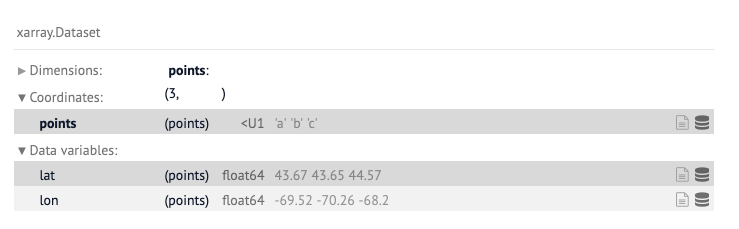

In [ ]:
_point_coords = {"points": ["a", "b", "c"]}
_lat = xr.DataArray([43.66631, 43.64694, 44.57038], coords=_point_coords)
_lon = xr.DataArray(
    [-69.52353, -70.25663, -68.19852], coords=_point_coords
)
points = xr.Dataset({"lat": _lat, "lon": _lon})
points

In [ ]:
def sel_ocean_points(da, pts, window=1.0):
    """Pointwise-select `da` at each (lat, lon) in `pts`, snapping to ocean cells.

    Handles two gotchas of point extraction from OISST-style grids:

    - **Longitude convention** - converts the points' -180..180 longitudes to
      0..360 when that's what the grid uses (detected from `da.lon.max()`).
    - **Land cells** - a point whose nearest cell is all-null (land) is snapped
      to the nearest non-null (ocean) cell within +/-`window` degrees, using
      the first timestep's null mask as the land/ocean mask.

    Returns a DataArray with a `points` dimension (labels from `pts`), the
    chosen cell's lat/lon as coordinates, and a boolean `snapped` coordinate
    marking points that were moved off land.
    """
    lon_max = float(da.lon.max())
    lons = pts["lon"] % 360 if lon_max > 180 else pts["lon"]
    ocean = da.isel(time=0).notnull().drop_vars("time", errors="ignore")

    series = []
    snapped = []
    for i in range(pts.sizes["points"]):
        t_lat, t_lon = float(pts["lat"][i]), float(lons[i])
        cell = da.sel(lat=t_lat, lon=t_lon, method="nearest")
        if bool(cell.isnull().all()):
            win = da.sel(
                lat=slice(t_lat - window, t_lat + window),
                lon=slice(t_lon - window, t_lon + window),
            )
            dist = (win.lat - t_lat) ** 2 + (win.lon - t_lon) ** 2
            idx = dist.where(ocean.sel(lat=win.lat, lon=win.lon)).argmin(
                dim=("lat", "lon")
            )
            cell = win.isel(idx)
            snapped.append(True)
        else:
            snapped.append(False)
        series.append(cell)

    out = xr.concat(series, dim=pts["points"])
    return out.assign_coords(snapped=("points", snapped))

In [ ]:
points_sst = sel_ocean_points(
    monthly_ds["sst_mean"].squeeze(drop=True), points
)

_rows = "\n".join(
    f"| {str(points_sst['points'][i].item())} "
    f"| {float(points['lat'][i]):.5f}, {float(points['lon'][i]):.5f} "
    f"| {float(points_sst.lat[i]):.3f}, {float(points_sst.lon[i]) - 360:.3f} "
    f"| {'yes' if bool(points_sst.snapped[i]) else 'no'} "
    f"| {int(points_sst.isel(points=i).isnull().sum())} |"
    for i in range(points_sst.sizes["points"])
)
mo.md(
    "| point | requested (lat, lon) | cell used (lat, lon) | snapped off land? | nulls |\n"
    "| --- | --- | --- | --- | --- |\n" + _rows
)

Ancestor raised: An ancestor raised an exception (ValueError)

In [ ]:
_fig2, _ax2 = plt.subplots(figsize=(9, 4))
for _i in range(points_sst.sizes["points"]):
    _r = points_sst.isel(points=_i)
    _ax2.plot(
        _r.time,
        _r,
        marker="o",
        label=f"{str(_r['points'].item())} ({float(_r.lat):.2f}, {float(_r.lon) - 360:.2f})"
        + (" [snapped]" if bool(_r.snapped) else ""),
    )
_ax2.set_title(
    "OISST monthly mean SST - pointwise selection with ocean snapping"
)
_ax2.set_ylabel("sst_mean (°C)")
_ax2.legend()
_ax2.grid(alpha=0.3)
_fig2.tight_layout()
_fig2

Ancestor raised: An ancestor raised an exception (ValueError)